# Phân tích mức tiêu hao nhiên liệu

## 1. ĐỌC DỮ LIỆU

Dữ liệu `mpg.csv` gồm các thông tin như sau:

- **mpg**: Miles/(US) gallon số gallon xăng trên 1 dặm
- **cylinders:** số lượng xilanh
- **displacement:**  Displacement/ dung tích xilanh (cu.in / $inches^3$)
- **horsepower:** công suất theo mã lực
- **weight:** trọng lượng (pound)
- **acceleration:** Gia tốc
- **model_year:** Năm sản xuất
- **origin:** Xuất xứ
- **name:** Tên dòng xe


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Đọc dữ liệu từ file mpg.csv
df = pd.read_csv("mpg.csv")
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


## 2. TÌM HIỂU DỮ LIỆU

### 2.1 Kiểm tra có dòng nào không có dữ liệu?

In [3]:
# Kiểm tra số lượng giá trị null theo từng cột
print("Số lượng giá trị null trong từng cột:")
print(df.isnull().sum())

# Đếm tổng số dòng chứa ít nhất 1 giá trị null
null_rows = df[df.isnull().any(axis=1)]
print(f"\nTổng số dòng chứa giá trị thiếu: {len(null_rows)}")

Số lượng giá trị null trong từng cột:
mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
name            0
dtype: int64

Tổng số dòng chứa giá trị thiếu: 6


### 2.2 Xóa các dòng không có dữ liệu


In [4]:
# Xóa các dòng thiếu dữ liệu
df = df.dropna().reset_index(drop=True)
print(f"Kích thước dữ liệu sau khi xóa: {df.shape}")

Kích thước dữ liệu sau khi xóa: (392, 9)


### 2.3 Tìm trung binh, trung vị của các thuộc tính: 'cylinders', 'horsepower', 'weight'

In [5]:
cols = ["cylinders", "horsepower", "weight"]

# Chuyển đổi thuộc tính horsepower sang kiểu số (nếu có dữ liệu dạng chuỗi)
df["horsepower"] = pd.to_numeric(df["horsepower"], errors="coerce")
df = df.dropna(subset=cols)

for col in cols:
  mean_val = df[col].mean()
  median_val = df[col].median()
  print(
      f"- Thuộc tính {col}: Trung bình = {mean_val:.2f}, Trung vị ="
      f" {median_val}"
  )

- Thuộc tính cylinders: Trung bình = 5.47, Trung vị = 4.0
- Thuộc tính horsepower: Trung bình = 104.47, Trung vị = 93.5
- Thuộc tính weight: Trung bình = 2977.58, Trung vị = 2803.5


### 2.4 Tìm miền giá trị và miền phân vị của thuộc tính 'mpg'

In [6]:
# Miền giá trị = Max - Min
range_mpg = df["mpg"].max() - df["mpg"].min()

# Miền phân vị (IQR) = Q3 - Q1
q1 = df["mpg"].quantile(0.25)
q3 = df["mpg"].quantile(0.75)
iqr_mpg = q3 - q1

print("- mpg, miền giá trị: ", range_mpg)
print("- mpg, miền phân vị: ", iqr_mpg)

- mpg, miền giá trị:  37.6
- mpg, miền phân vị:  12.0


## 3. SO SÁNH MỨC TIÊU HAO NHIÊN LIỆU TRUNG BÌNH CỦA CÁC DÒNG XE DỰA TRÊN XUẤT XỨ

So sánh mức tiêu hao nhiên liệu trung bình của các dòng xe Mỹ, Nhật và Châu Âu

origin
europe    27.602941
japan     30.450633
usa       20.033469
Name: mpg, dtype: float64


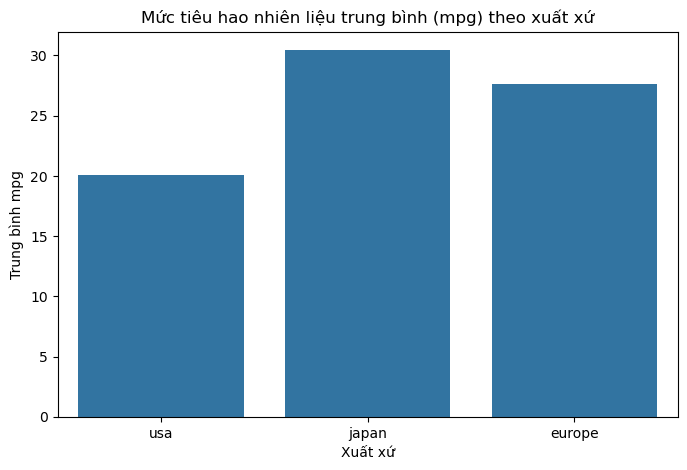

In [7]:
# Bảng giá trị trung bình mpg theo từng quốc gia/xuất xứ
avg_mpg_by_origin = df.groupby("origin")["mpg"].mean()
print(avg_mpg_by_origin)

# Biểu đồ so sánh
plt.figure(figsize=(8, 5))
sns.barplot(x="origin", y="mpg", data=df, errorbar=None)
plt.title("Mức tiêu hao nhiên liệu trung bình (mpg) theo xuất xứ")
plt.xlabel("Xuất xứ")
plt.ylabel("Trung bình mpg")
plt.show()

## 4. VẼ HISTOGRAM TRỌNG LƯỢNG CÁC XE

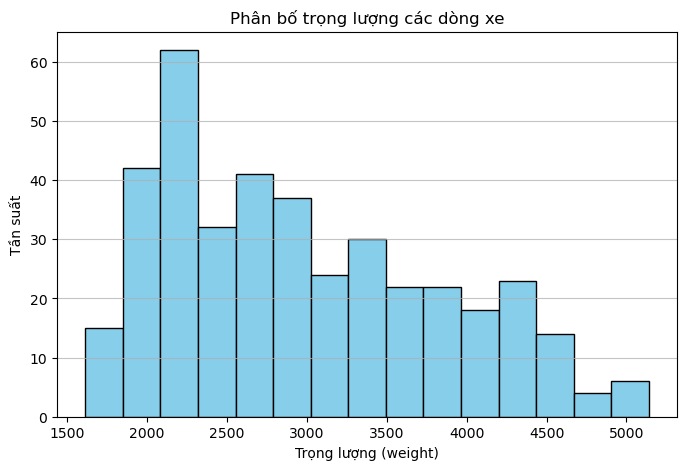

In [8]:
plt.figure(figsize=(8, 5))
plt.hist(df["weight"], bins=15, color="skyblue", edgecolor="black")
plt.title("Phân bố trọng lượng các dòng xe")
plt.xlabel("Trọng lượng (weight)")
plt.ylabel("Tần suất")
plt.grid(axis="y", alpha=0.75)
plt.show()

## 5. TÍNH TỶ LỆ CÁC DÒNG XE DỰA TRÊN XUẤT XỨ

Tỷ lệ % các dòng xe theo xuất xứ:
origin
usa       62.500000
japan     20.153061
europe    17.346939
Name: proportion, dtype: float64


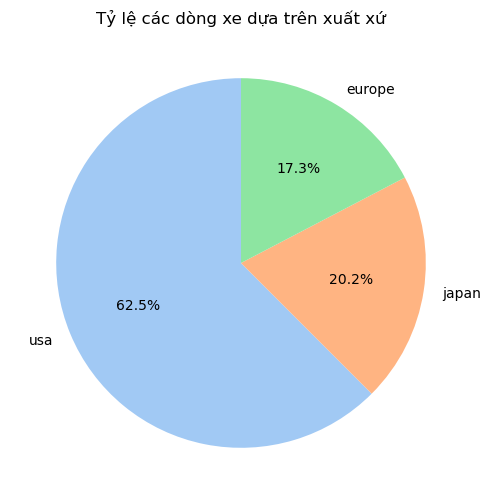

In [9]:
# Tính tỷ lệ phần trăm
origin_ratios = df["origin"].value_counts(normalize=True) * 100
print("Tỷ lệ % các dòng xe theo xuất xứ:")
print(origin_ratios)

# Vẽ biểu đồ tròn
plt.figure(figsize=(6, 6))
df["origin"].value_counts().plot(
    kind="pie", autopct="%.1f%%", startangle=90, colors=sns.color_palette("pastel")
)
plt.title("Tỷ lệ các dòng xe dựa trên xuất xứ")
plt.ylabel("")
plt.show()

## 6. VẼ BOXPLOT SO SÁNH CÔNG SUẤT CỦA CÁC DÒNG XE THẬP NIÊN 70, 80

Lưu ý: Các dòng xe thập niên 70 (1970 - 1979), thập niên 80 (1980 - 1989)

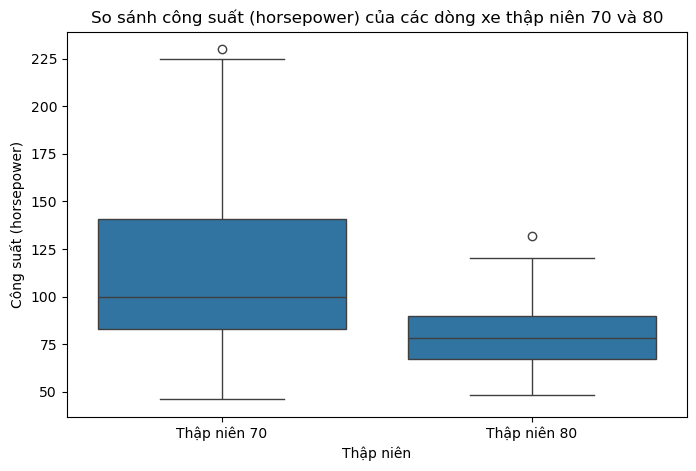

In [10]:
# Phân loại thập niên (hỗ trợ cả định dạng năm 2 chữ số 70-89 hoặc 4 chữ số 1970-1989)
def get_decade(year):
  if (70 <= year <= 79) or (1970 <= year <= 1979):
    return "Thập niên 70"
  elif (80 <= year <= 89) or (1980 <= year <= 1989):
    return "Thập niên 80"
  return "Khác"


df["decade"] = df["model_year"].apply(get_decade)
df_decade = df[df["decade"].isin(["Thập niên 70", "Thập niên 80"])]

# Biểu đồ Boxplot
plt.figure(figsize=(8, 5))
sns.boxplot(x="decade", y="horsepower", data=df_decade)
plt.title("So sánh công suất (horsepower) của các dòng xe thập niên 70 và 80")
plt.xlabel("Thập niên")
plt.ylabel("Công suất (horsepower)")
plt.show()

## 7. KHẢO SÁT MỨC TIÊU HAO NHIÊN LIỆU

### 7.1 Với số lượng xi lanh

Thử vẽ bằng đồ thị scatter plot.

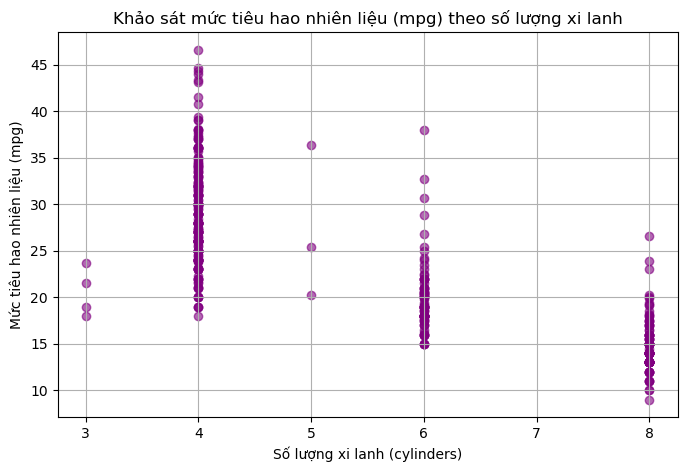

In [11]:
plt.figure(figsize=(8, 5))
plt.scatter(df["cylinders"], df["mpg"], color="purple", alpha=0.6)
plt.title("Khảo sát mức tiêu hao nhiên liệu (mpg) theo số lượng xi lanh")
plt.xlabel("Số lượng xi lanh (cylinders)")
plt.ylabel("Mức tiêu hao nhiên liệu (mpg)")
plt.grid(True)
plt.show()

### 7.2 Với công suất theo mã lực

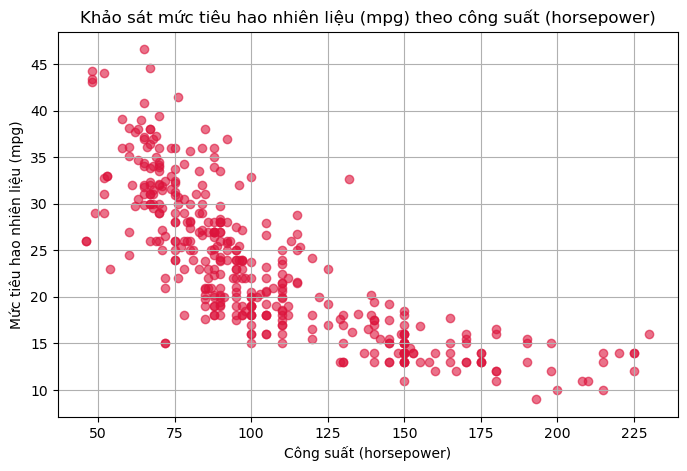

In [12]:
plt.figure(figsize=(8, 5))
plt.scatter(df["horsepower"], df["mpg"], color="crimson", alpha=0.6)
plt.title("Khảo sát mức tiêu hao nhiên liệu (mpg) theo công suất (horsepower)")
plt.xlabel("Công suất (horsepower)")
plt.ylabel("Mức tiêu hao nhiên liệu (mpg)")
plt.grid(True)
plt.show()

### 7.3 Với gia tốc

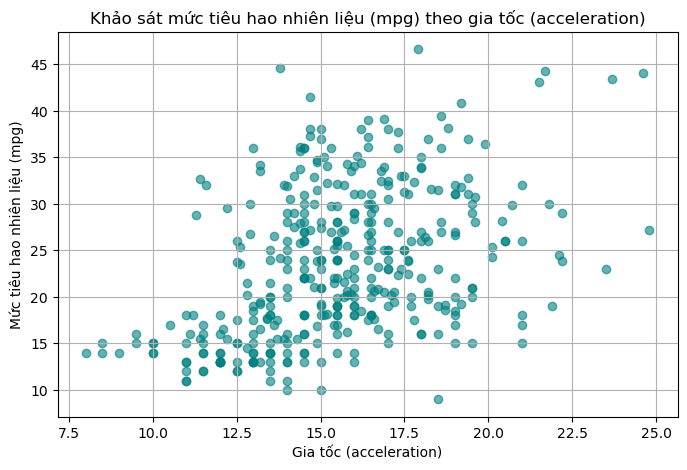

In [13]:
plt.figure(figsize=(8, 5))
plt.scatter(df["acceleration"], df["mpg"], color="teal", alpha=0.6)
plt.title("Khảo sát mức tiêu hao nhiên liệu (mpg) theo gia tốc (acceleration)")
plt.xlabel("Gia tốc (acceleration)")
plt.ylabel("Mức tiêu hao nhiên liệu (mpg)")
plt.grid(True)
plt.show()

### 7.4 Với năm sản xuất

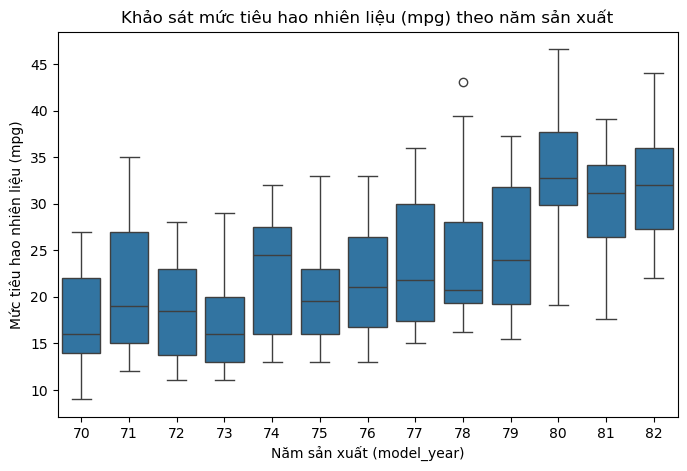

In [14]:
plt.figure(figsize=(8, 5))
sns.boxplot(x="model_year", y="mpg", data=df)
plt.title("Khảo sát mức tiêu hao nhiên liệu (mpg) theo năm sản xuất")
plt.xlabel("Năm sản xuất (model_year)")
plt.ylabel("Mức tiêu hao nhiên liệu (mpg)")
plt.show()